# Cover Letter Feature Analysis — Summary

**Corpus:** 4 000 cover letters — 10 job ads × 50 candidates × 8 writer models.

**Features extracted:** surface structure (length, punctuation), language complexity
(vocabulary richness, readability), sentiment & affect (VADER, VAD valence/arousal/dominance),
emotion probabilities (j-hartmann distilroberta), sentence embeddings (all-MiniLM-L6-v2),
and cosine similarity to the job description.

**Analysis pipeline:**
1. What do the models produce? — feature profiles
2. What vocabulary do they use? — keyness
3. Are they consistent across candidates? — embedding homogeneity & variance
4. Do they adapt to candidate quality? — tier sensitivity & distributions
5. Are they semantically similar across models? — cross-model similarity & deviation profiles
6. What do evaluators reward? — feature–score correlations


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
%matplotlib inline
plt.rcParams["figure.dpi"] = 130
sns.set_theme(style="whitegrid")

WRITER_COLORS = {
    "gpt-4o-mini":            "#1565C0",
    "gpt-5-mini":             "#42A5F5",
    "gemini-2.0-flash":       "#1B5E20",
    "gemini-3-flash-preview": "#66BB6A",
    "claude-haiku-4-5":       "#E65100",
    "deepseek-chat":          "#4A148C",
    "deepseek-r1-8b":         "#AB47BC",
    "llama3.1-8b":            "#5D4037",
}
MODEL_DISPLAY = {
    "gpt-4o-mini":            "GPT-4o mini",
    "gpt-5-mini":             "GPT-5 mini",
    "gemini-2.0-flash":       "Gemini 2.0 Flash",
    "gemini-3-flash-preview": "Gemini 3 Flash",
    "claude-haiku-4-5":       "Claude Haiku 4.5",
    "deepseek-chat":          "DeepSeek Chat",
    "deepseek-r1-8b":         "DeepSeek R1 8B",
    "llama3.1-8b":            "Llama 3.1 8B",
}
WRITERS = list(WRITER_COLORS)

df = pd.read_parquet("output_eval/cl_features.parquet")
df["Tier"] = df["CV_Idx"].apply(lambda x: "High-Fit" if x <= 25 else "Moderate-Fit")
print(f"{len(df):,} rows | {df['Job_ID'].nunique()} jobs | "
      f"{df['Writer'].nunique()} writers | {df['CV_Idx'].nunique()} CVs/writer/job")


5,500 rows | 10 jobs | 11 writers | 50 CVs/writer/job


---
## 1. What Do Models Produce?

We examine four feature groups across models and candidate tiers
(High-Fit = CV_Idx 1–25, Moderate-Fit = 26–50).


### 1a. Length & Surface Structure

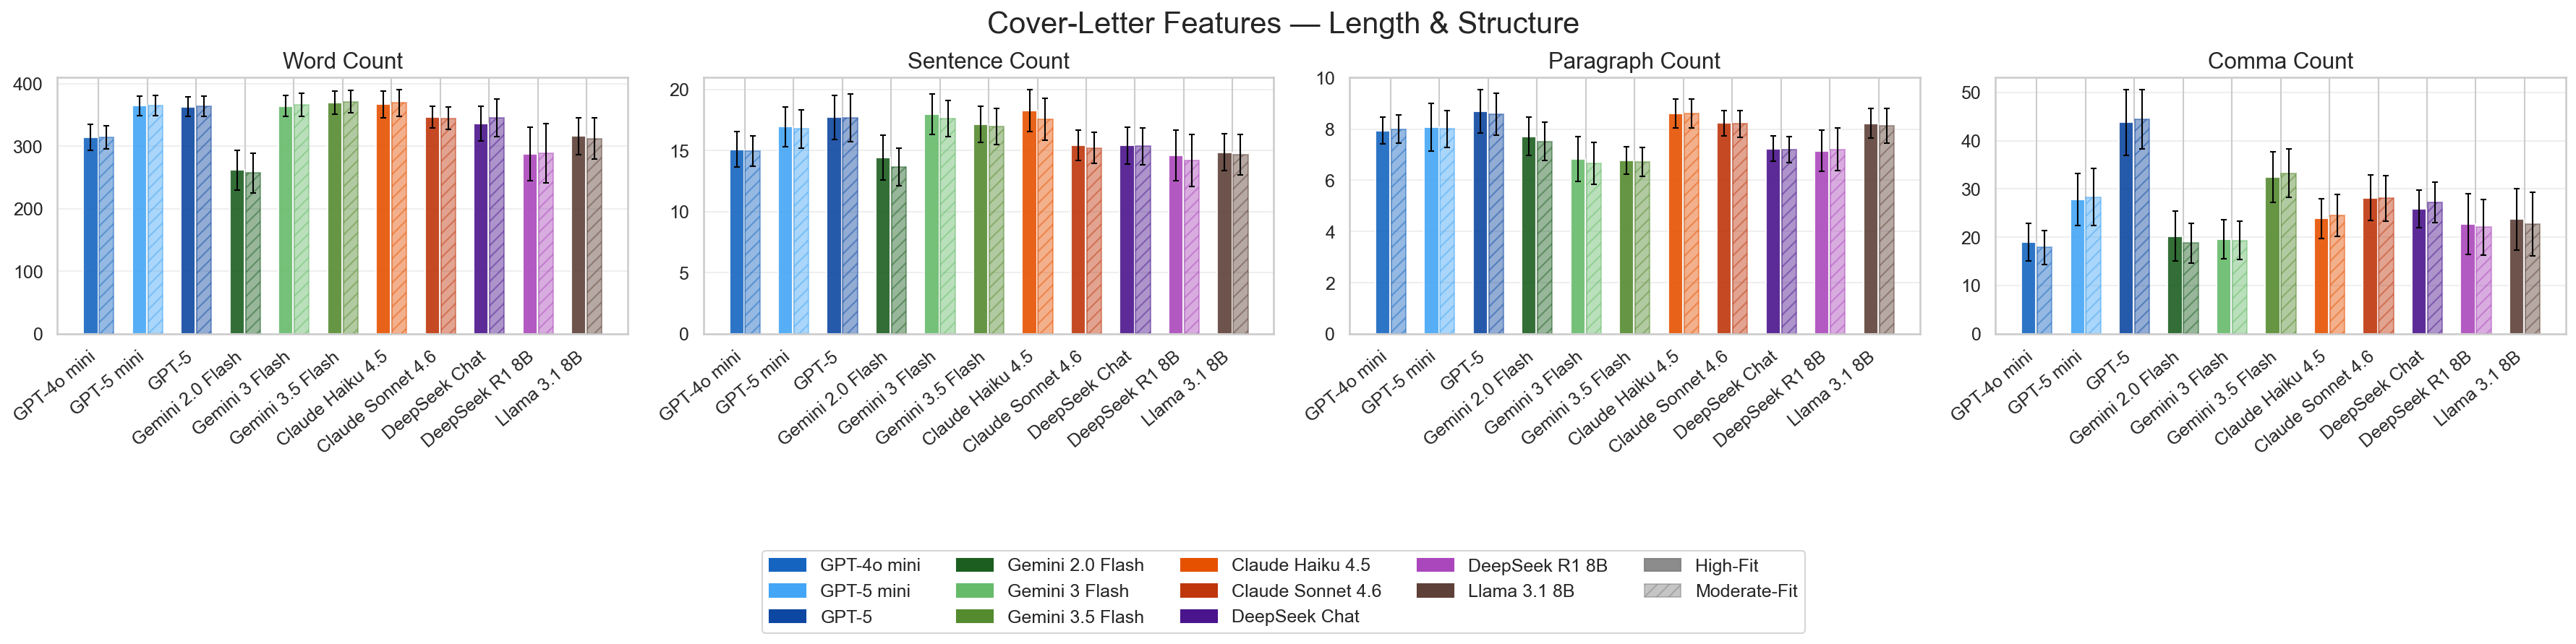

In [2]:
display(Image("output_plots/cl_features/cl_features_length_structure.png"))

Word count, sentence count, paragraph count, and comma use.
Models vary noticeably in verbosity — some consistently write longer letters regardless of the candidate.
Tier differences are generally small, suggesting length is more a model style than a candidate-adaptive signal.


### 1b. Language Complexity

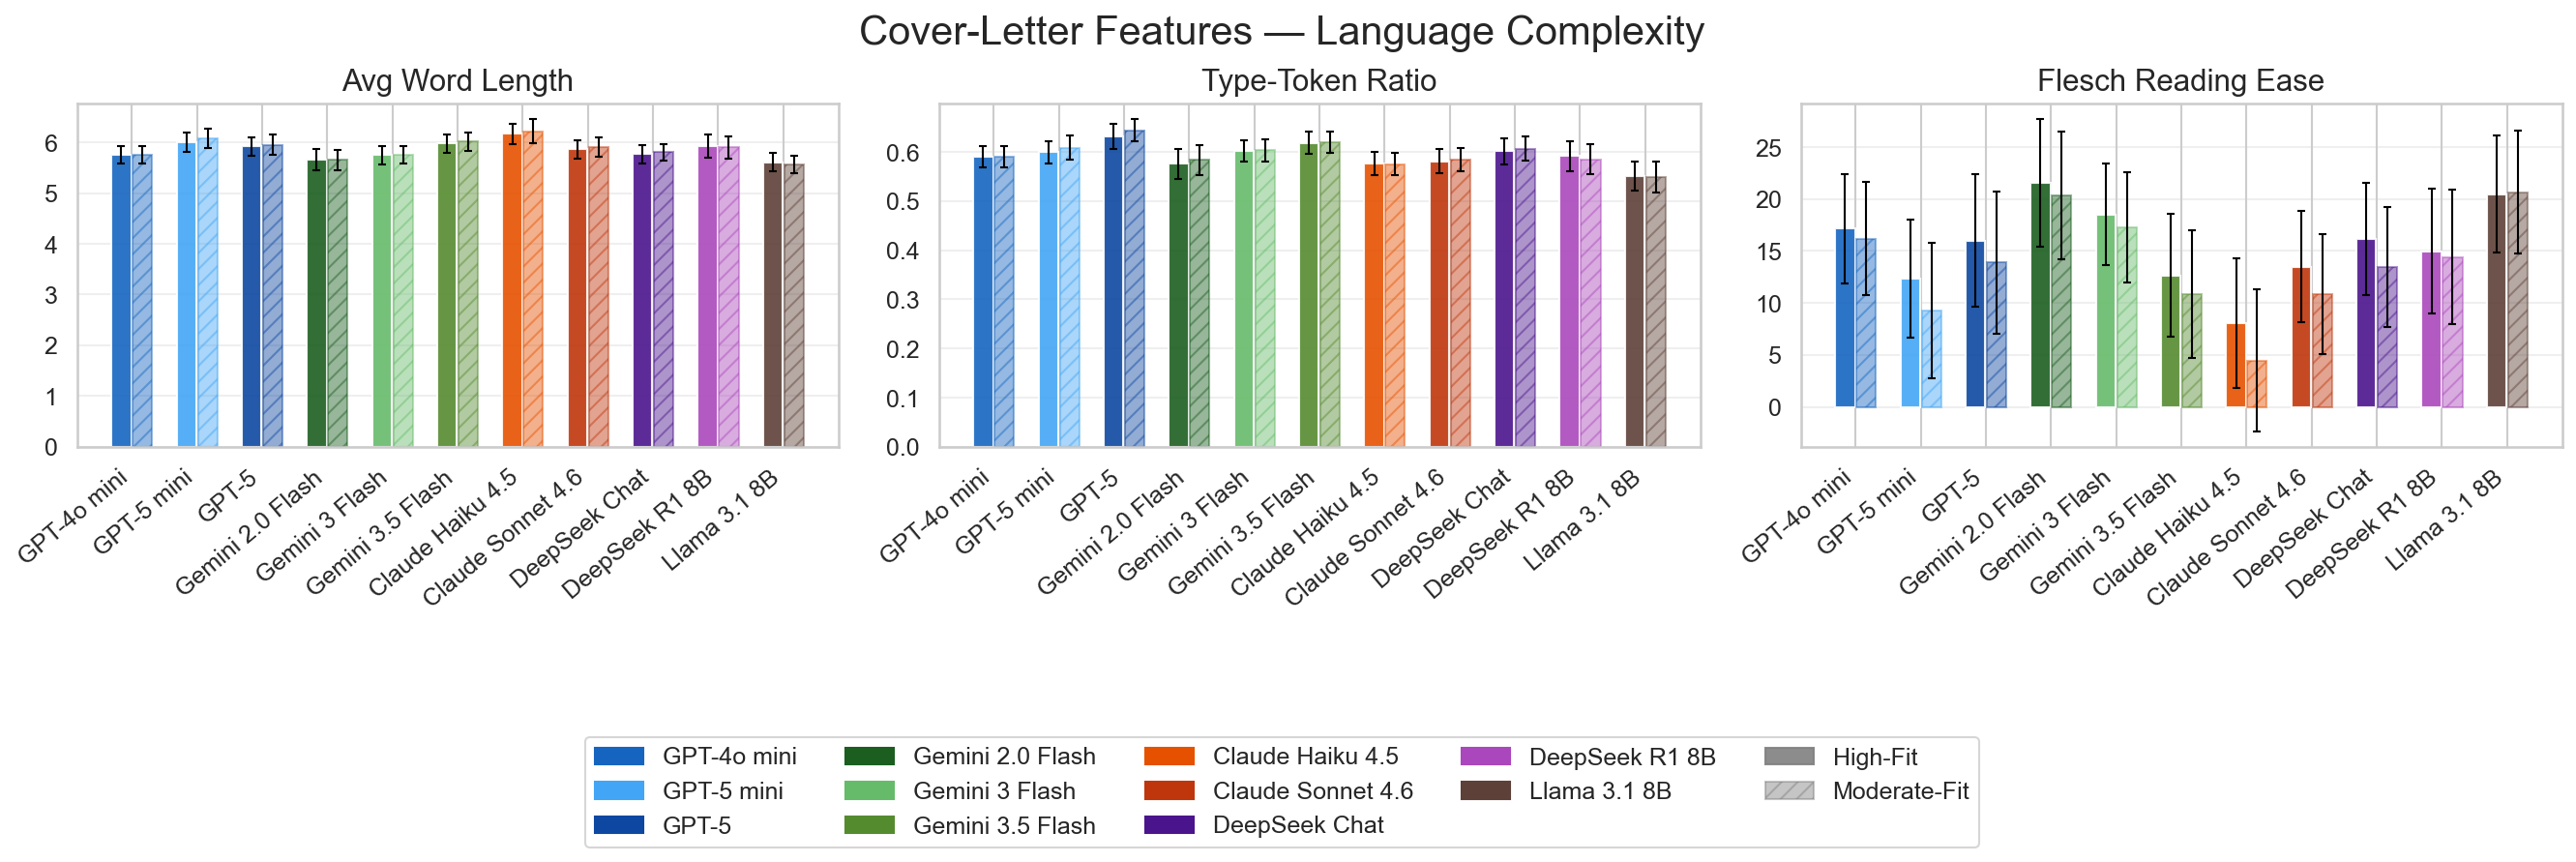

In [3]:
display(Image("output_plots/cl_features/cl_features_language_complexity.png"))

Average word length and type-token ratio (TTR) proxy **vocabulary richness**;
Flesch Reading Ease and Flesch-Kincaid Grade measure **readability**.
Together they capture whether a model favours sophisticated, varied vocabulary
vs. simple, repetitive phrasing. Models differ: some consistently use more complex language.


### 1c. Sentiment & Affect

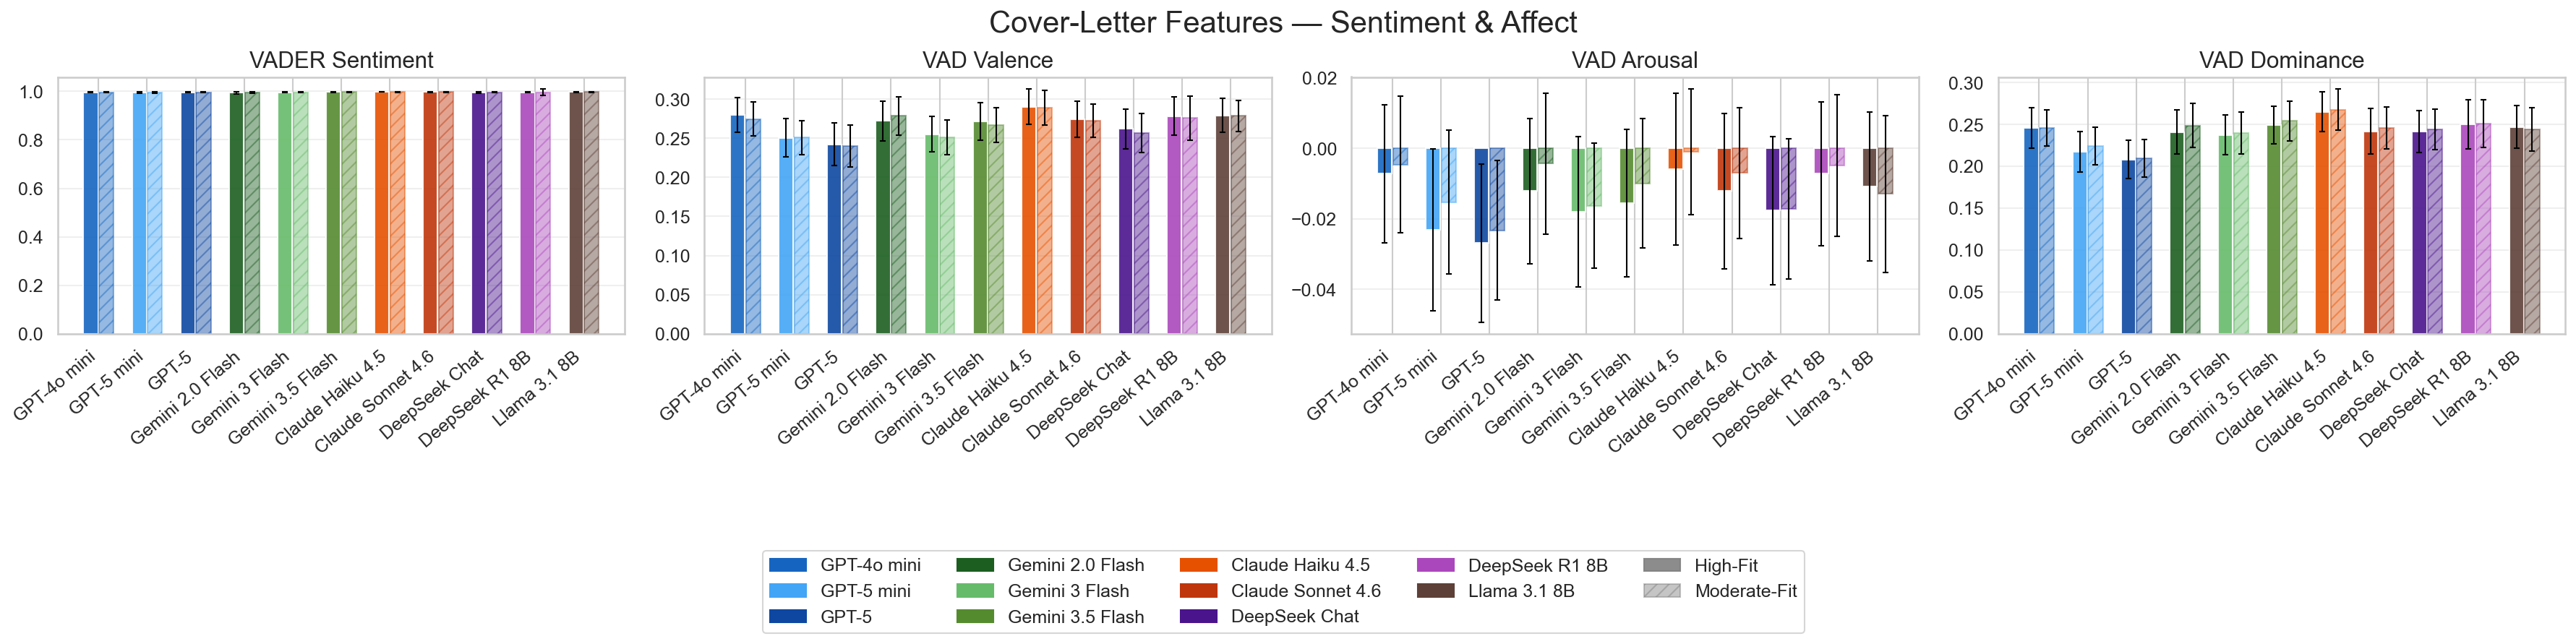

In [4]:
display(Image("output_plots/cl_features/cl_features_sentiment_affect.png"))

- **VADER compound** and **VAD Valence** both measure positive/negative tone.
  As expected for cover letters, both are near-ceiling for all models — this dimension is not discriminating.
- **VAD Arousal** captures energy level: excited/active vs. calm/measured.
- **VAD Dominance** captures assertiveness: confident/in-control vs. deferential/submissive.
  This is potentially the most informative of the four — does the model write assertively
  ("I will deliver") or tentatively ("I would hope to contribute")?


### 1d. Emotion Profile

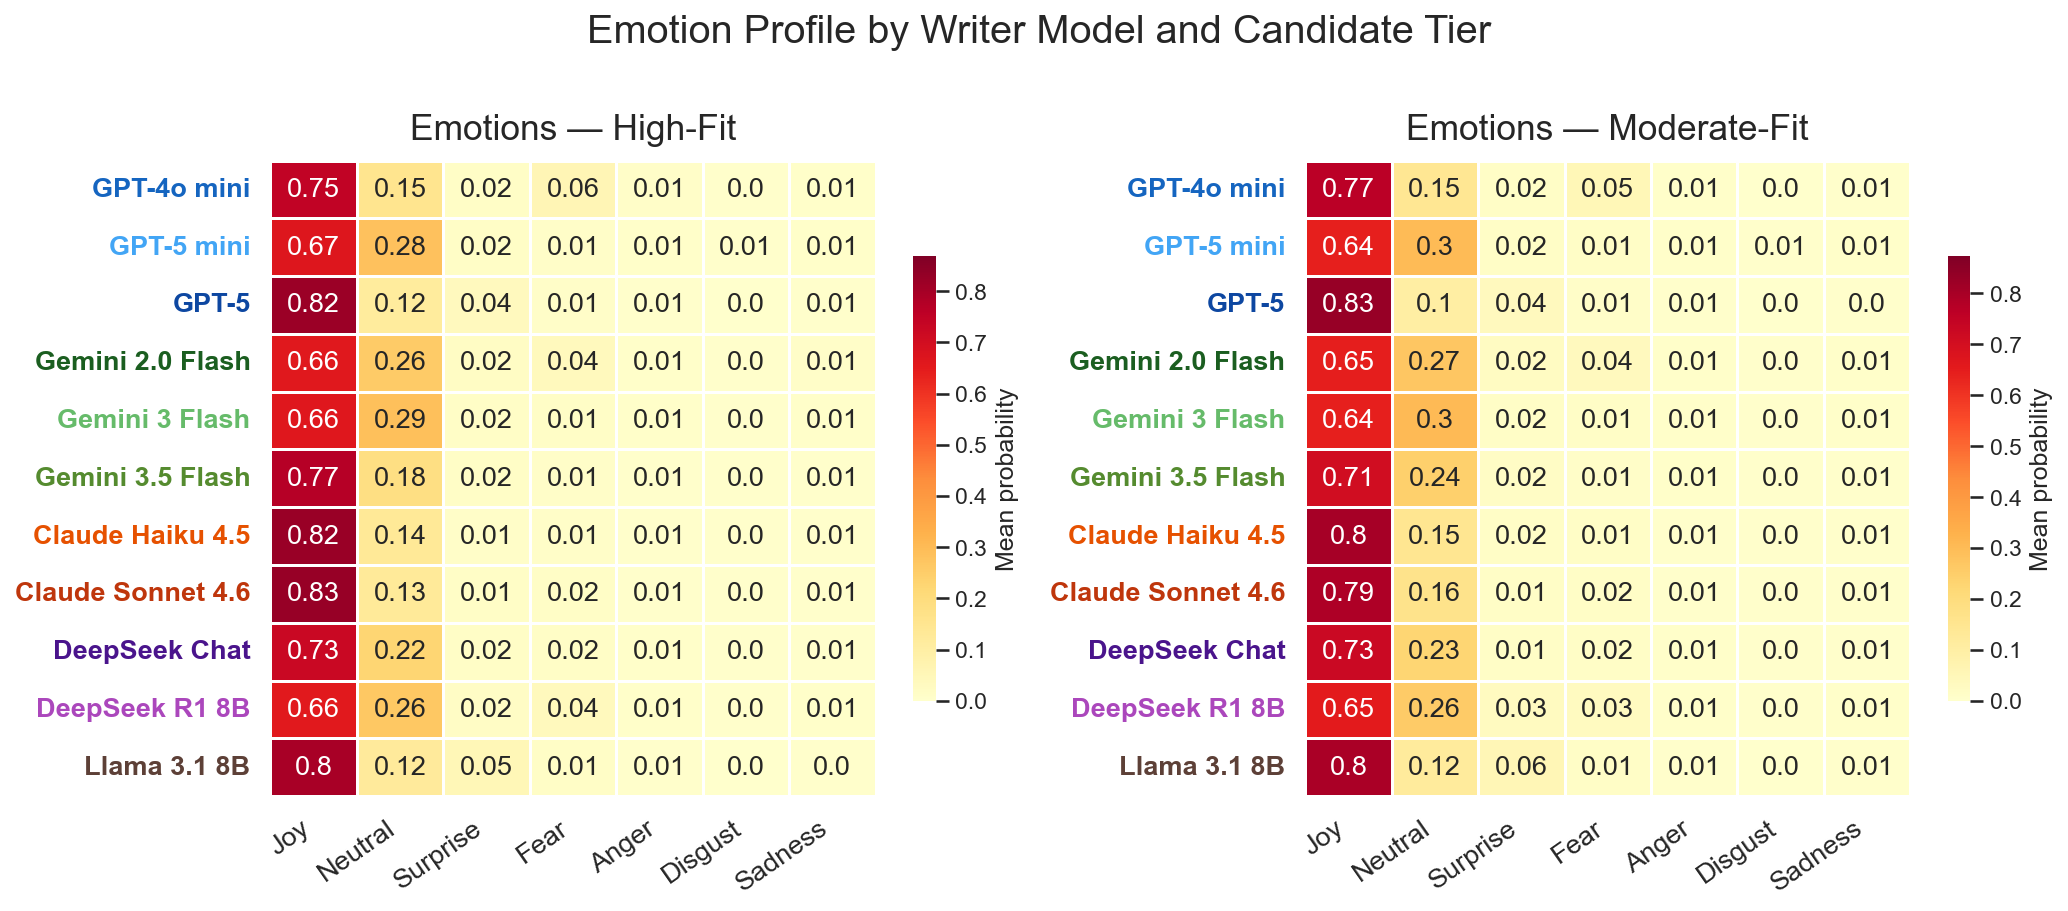

In [5]:
display(Image("output_plots/cl_features/cl_features_emotions_heatmap.png"))

Each cell shows the mean emotion probability for a given model (rows) and emotion (columns),
separately for High-Fit and Moderate-Fit candidates.
**Joy** and **Neutral** dominate, as expected for professional writing.
Differences between models are small but visible — some models are slightly more joyful,
others more neutral. Tier differences within models are minimal.


### 1e. Semantic Fit to Job Description

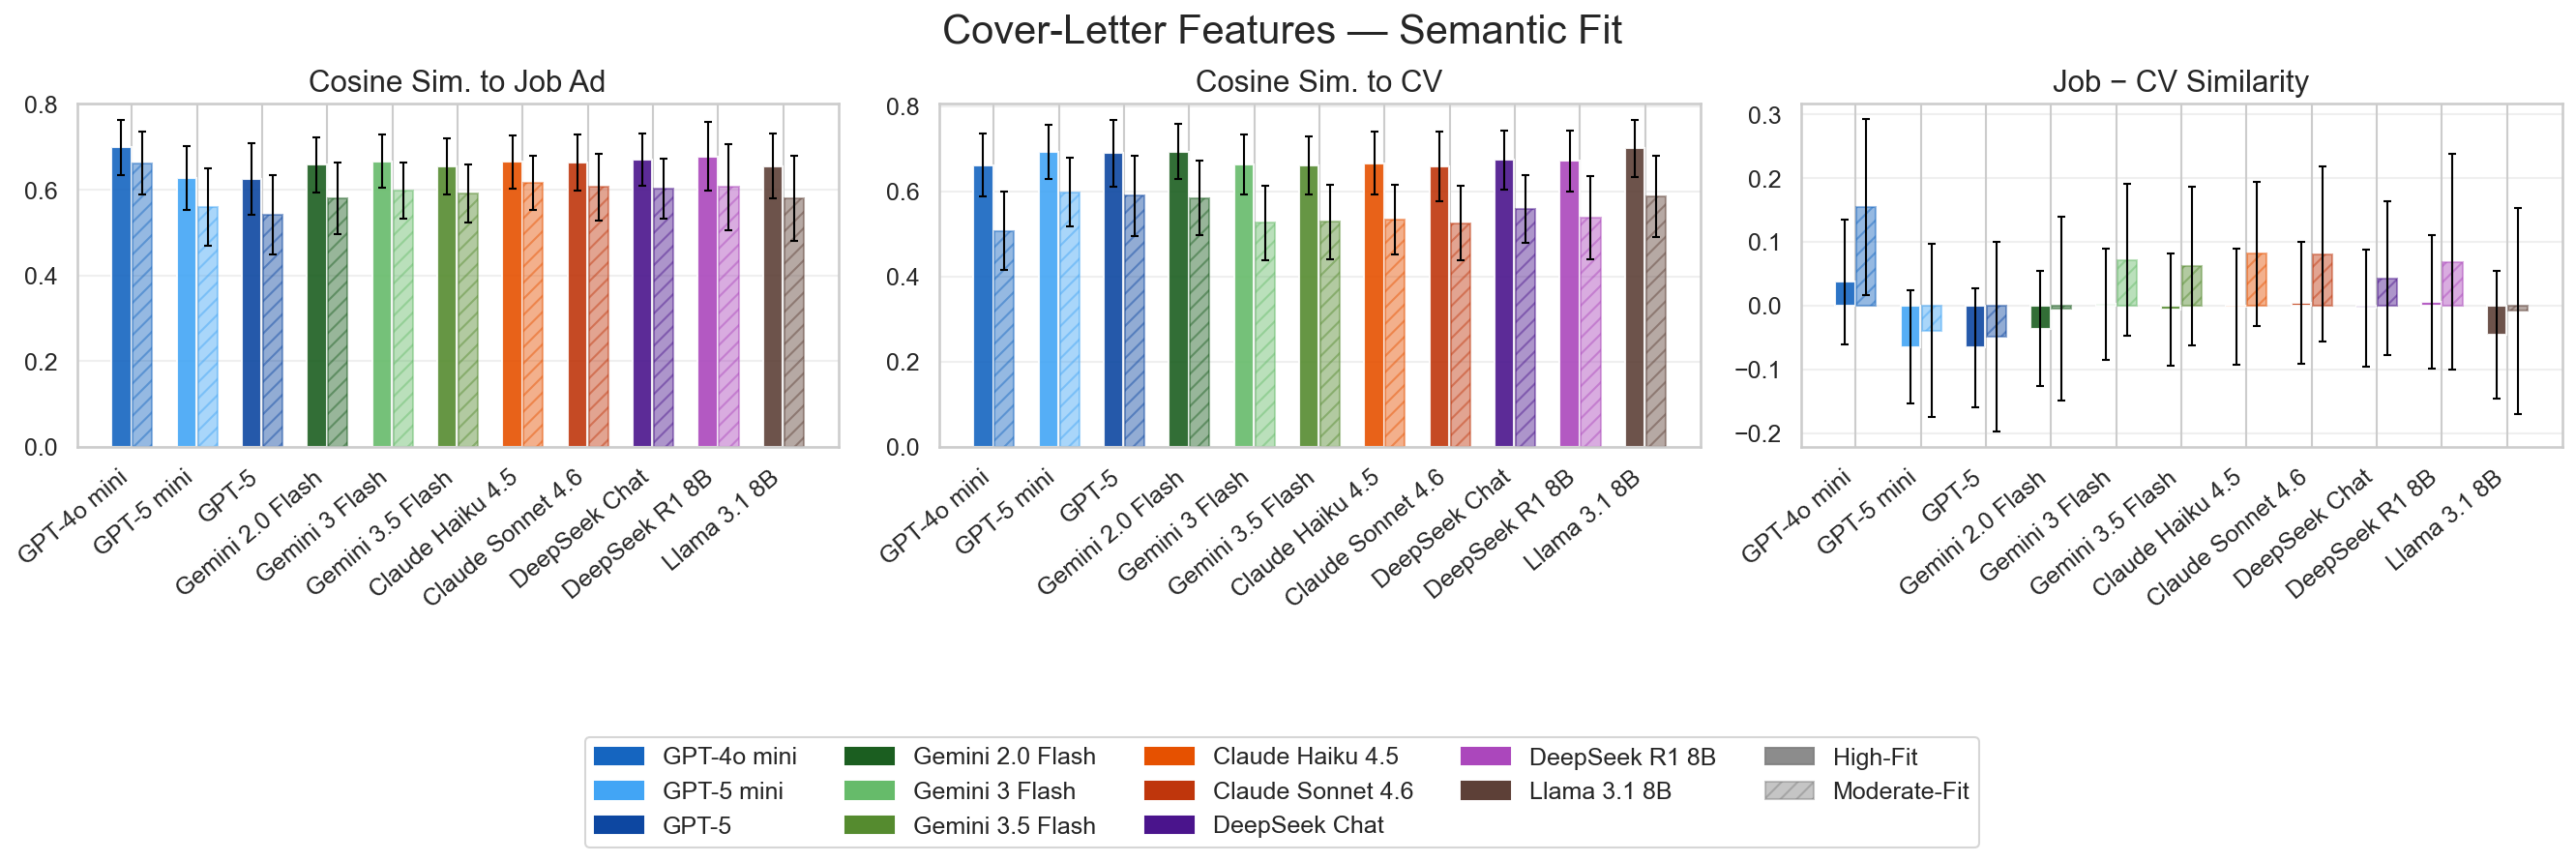

In [6]:
display(Image("output_plots/cl_features/cl_features_semantic_fit.png"))

Cosine similarity between the cover letter embedding and the job description embedding.
Models vary in how closely they mirror the language of the job ad.
High-Fit candidates tend to show slightly higher similarity (their CVs are already closer to the job),
but the model choice also plays a role.


---
## 2. What Vocabulary Do Models Use?

For each model, lemmas statistically over-represented relative to all other models pooled
(G² log-likelihood ratio, spaCy lemmatisation).
This reveals the lexical *fingerprint* of each model — the words it reaches for far more often than others.


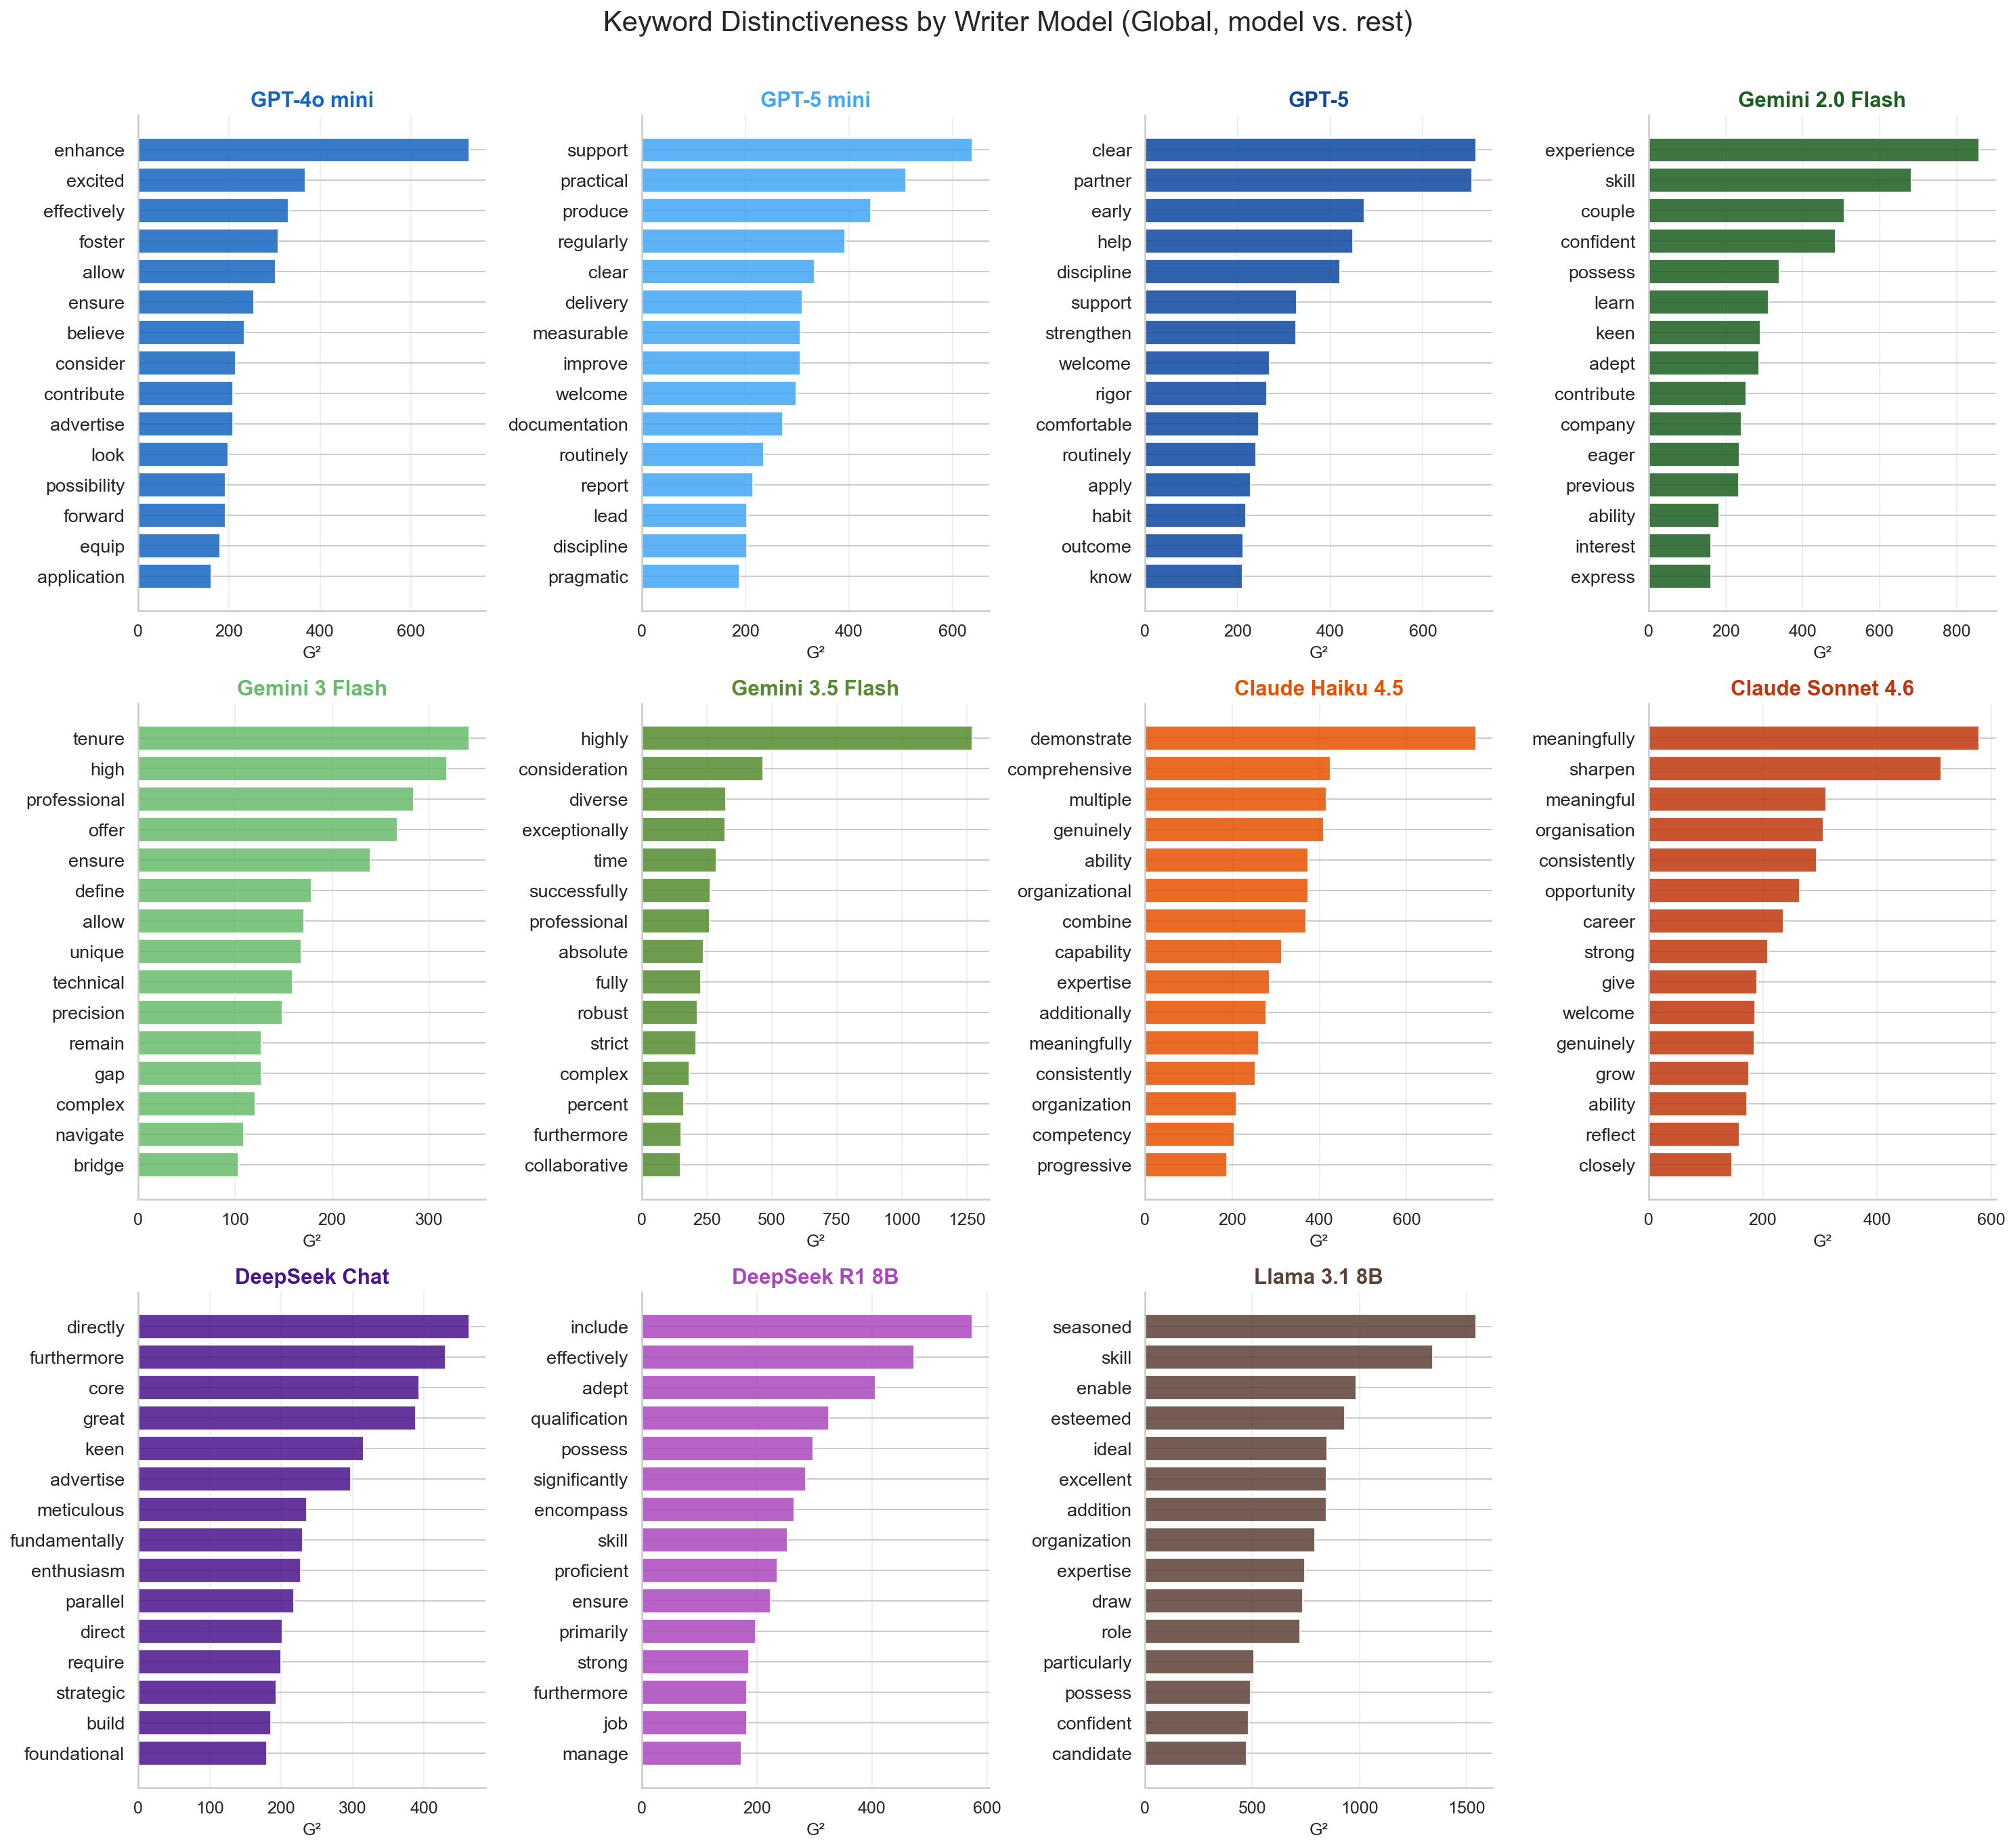

In [7]:
display(Image("output_plots/keyness/keyness_global.png"))

Despite semantic similarity across models (§5), each model has a distinctive vocabulary.
These lexical choices — invisible in the embedding space — may be what evaluator models detect and reward.


---
## 3. Are Models Consistent Across Candidates?

Does a model write essentially the same letter for all 50 candidates on a given job,
or does it adapt to each individual CV?


### 3a. Embedding Homogeneity

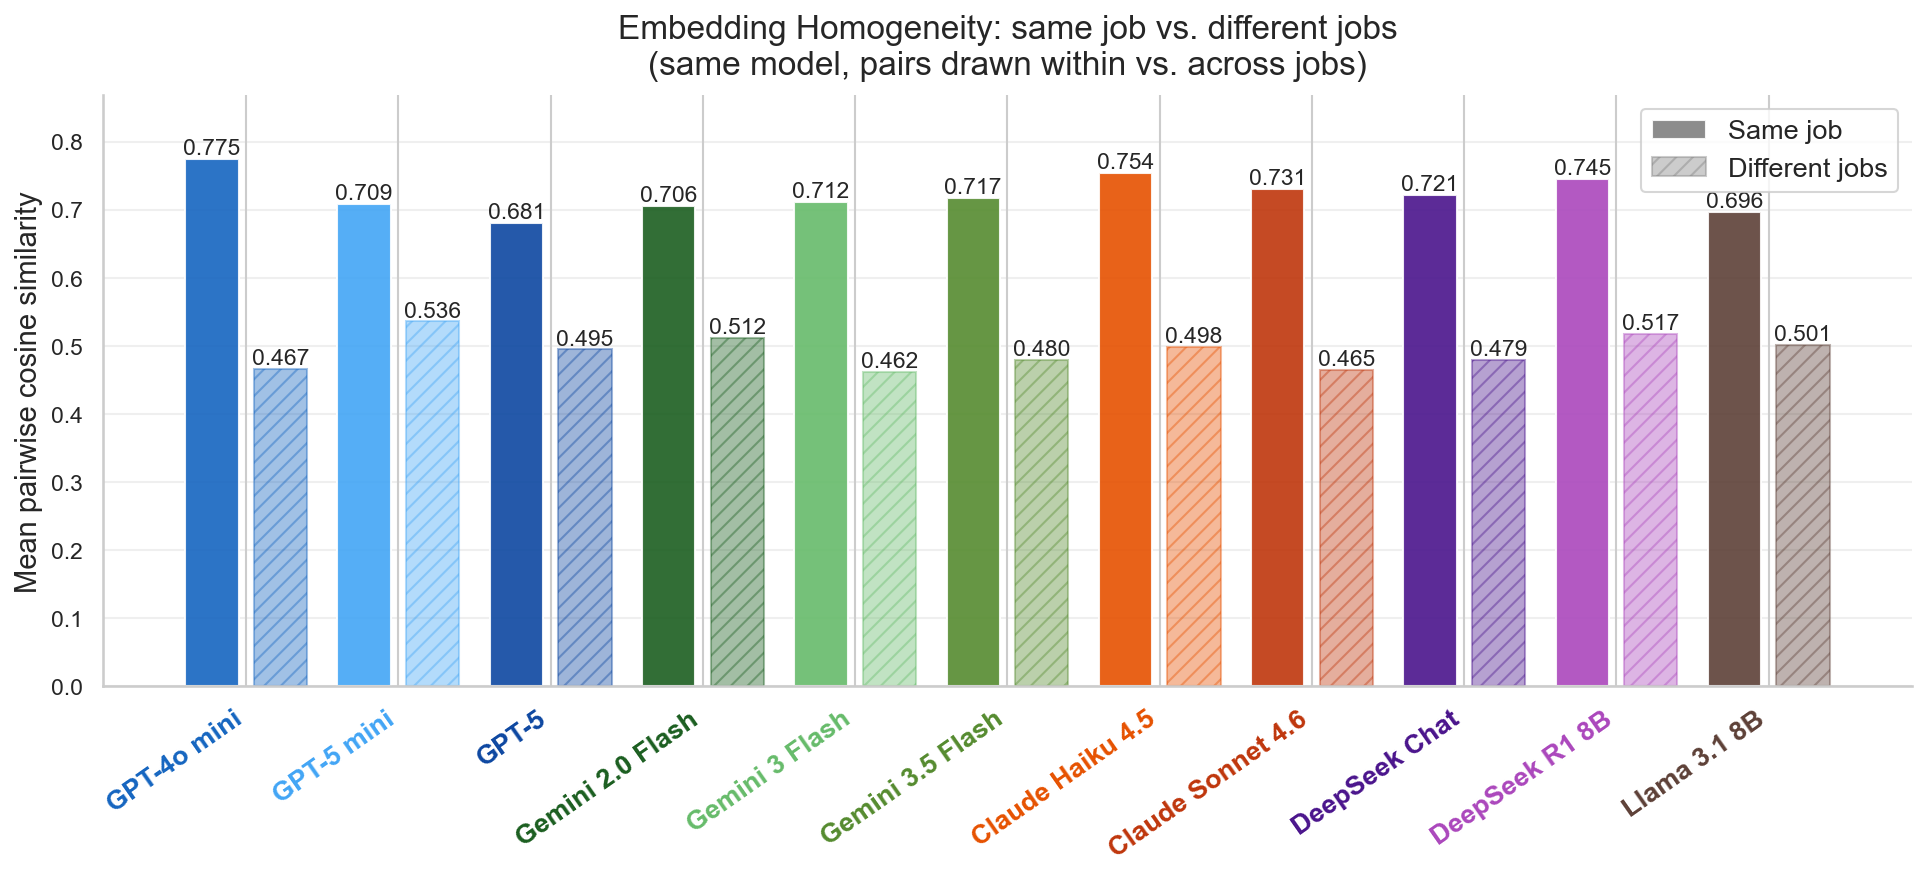

In [8]:
display(Image("output_plots/cl_features/cl_embedding_homogeneity.png"))

In [9]:
rows = []
for writer in WRITERS:
    sub     = df[df["Writer"] == writer].copy()
    job_ids = sub["Job_ID"].to_numpy(dtype=str)
    embs    = np.array(sub["embedding"].tolist(), dtype=np.float32)
    norms   = np.linalg.norm(embs, axis=1, keepdims=True)
    embs    = embs / np.where(norms == 0, 1, norms)
    sim     = embs @ embs.T
    same    = (job_ids[:, None] == job_ids[None, :])
    n       = len(embs)
    upper   = np.triu_indices(n, k=1)
    s, mask = sim[upper], same[upper]
    rows.append({"Model":       MODEL_DISPLAY[writer],
                 "Within-job":  round(float(s[mask].mean()),  4),
                 "Cross-job":   round(float(s[~mask].mean()), 4)})

hom = (pd.DataFrame(rows).set_index("Model")
         .sort_values("Within-job", ascending=False))
hom["Gap (within − cross)"] = (hom["Within-job"] - hom["Cross-job"]).round(4)
display(hom)


,Within-job,Cross-job,Gap (within − cross)
Model,,,
GPT-4o mini,0.7750,0.4666,0.3084
Claude Haiku 4.5,0.7542,0.4979,0.2563
DeepSeek R1 8B,0.7445,0.5170,0.2275
DeepSeek Chat,0.7215,0.4795,0.2420
Gemini 3 Flash,0.7117,0.4622,0.2495
GPT-5 mini,0.7086,0.5358,0.1728
Gemini 2.0 Flash,0.7056,0.5121,0.1935
Llama 3.1 8B,0.6964,0.5012,0.1952


**Key finding:** within-job similarity (0.70–0.78) is far higher than cross-job (0.46–0.54).
The *job description* drives the semantic content — models adapt to the job, not the candidate.
GPT-4o mini is the most homogeneous across candidates; Llama 3.1 8B preserves the most individuality.


### 3b. Variance Decomposition

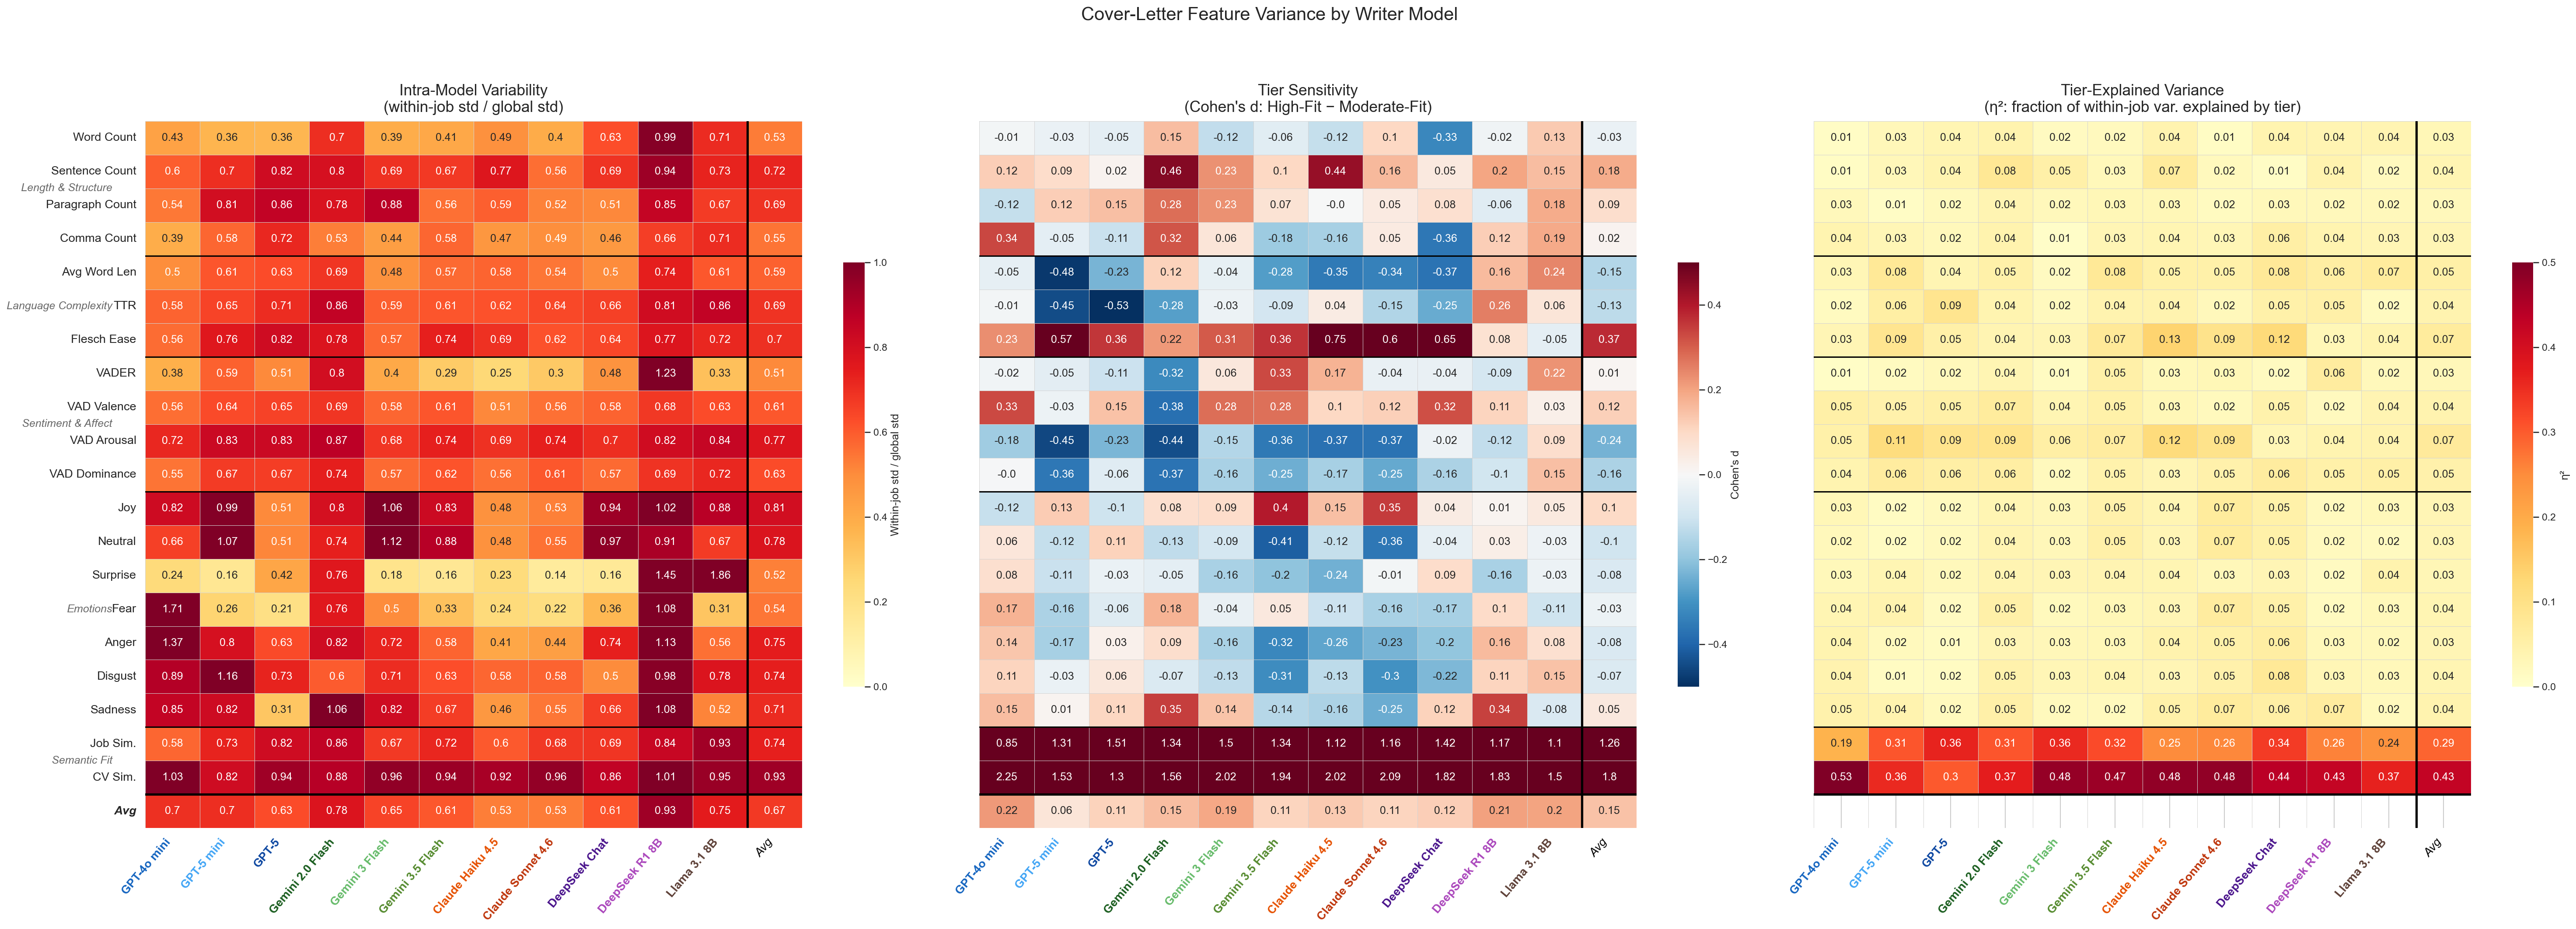

In [10]:
display(Image("output_plots/cl_features/cl_variance_heatmaps.png"))

Three panels:
- **η² (left):** fraction of within-job variance explained by the tier split.
  Values are generally low — the tier rarely explains a large share of within-job variance.
- **Within-job std / global std (middle):** total within-job variance per feature per model.
- **Cohen's d (right):** direction and size of the High-Fit vs. Moderate-Fit difference.
  Near zero across most features — models do not write systematically different letters
  for stronger vs. weaker candidates.


---
## 4. Do Models Adapt to Candidate Quality?

The variance heatmaps above (η², Cohen's d) already quantify this.
The tier sensitivity panel shows that for most models and features, the tier split
explains little within-job variance and Cohen's d is near zero — models do not write
systematically different letters for stronger vs. weaker candidates.


---
## 5. Are Models Semantically Similar to Each Other?

### 5a. Cross-Model Similarity (same candidate, different writer)


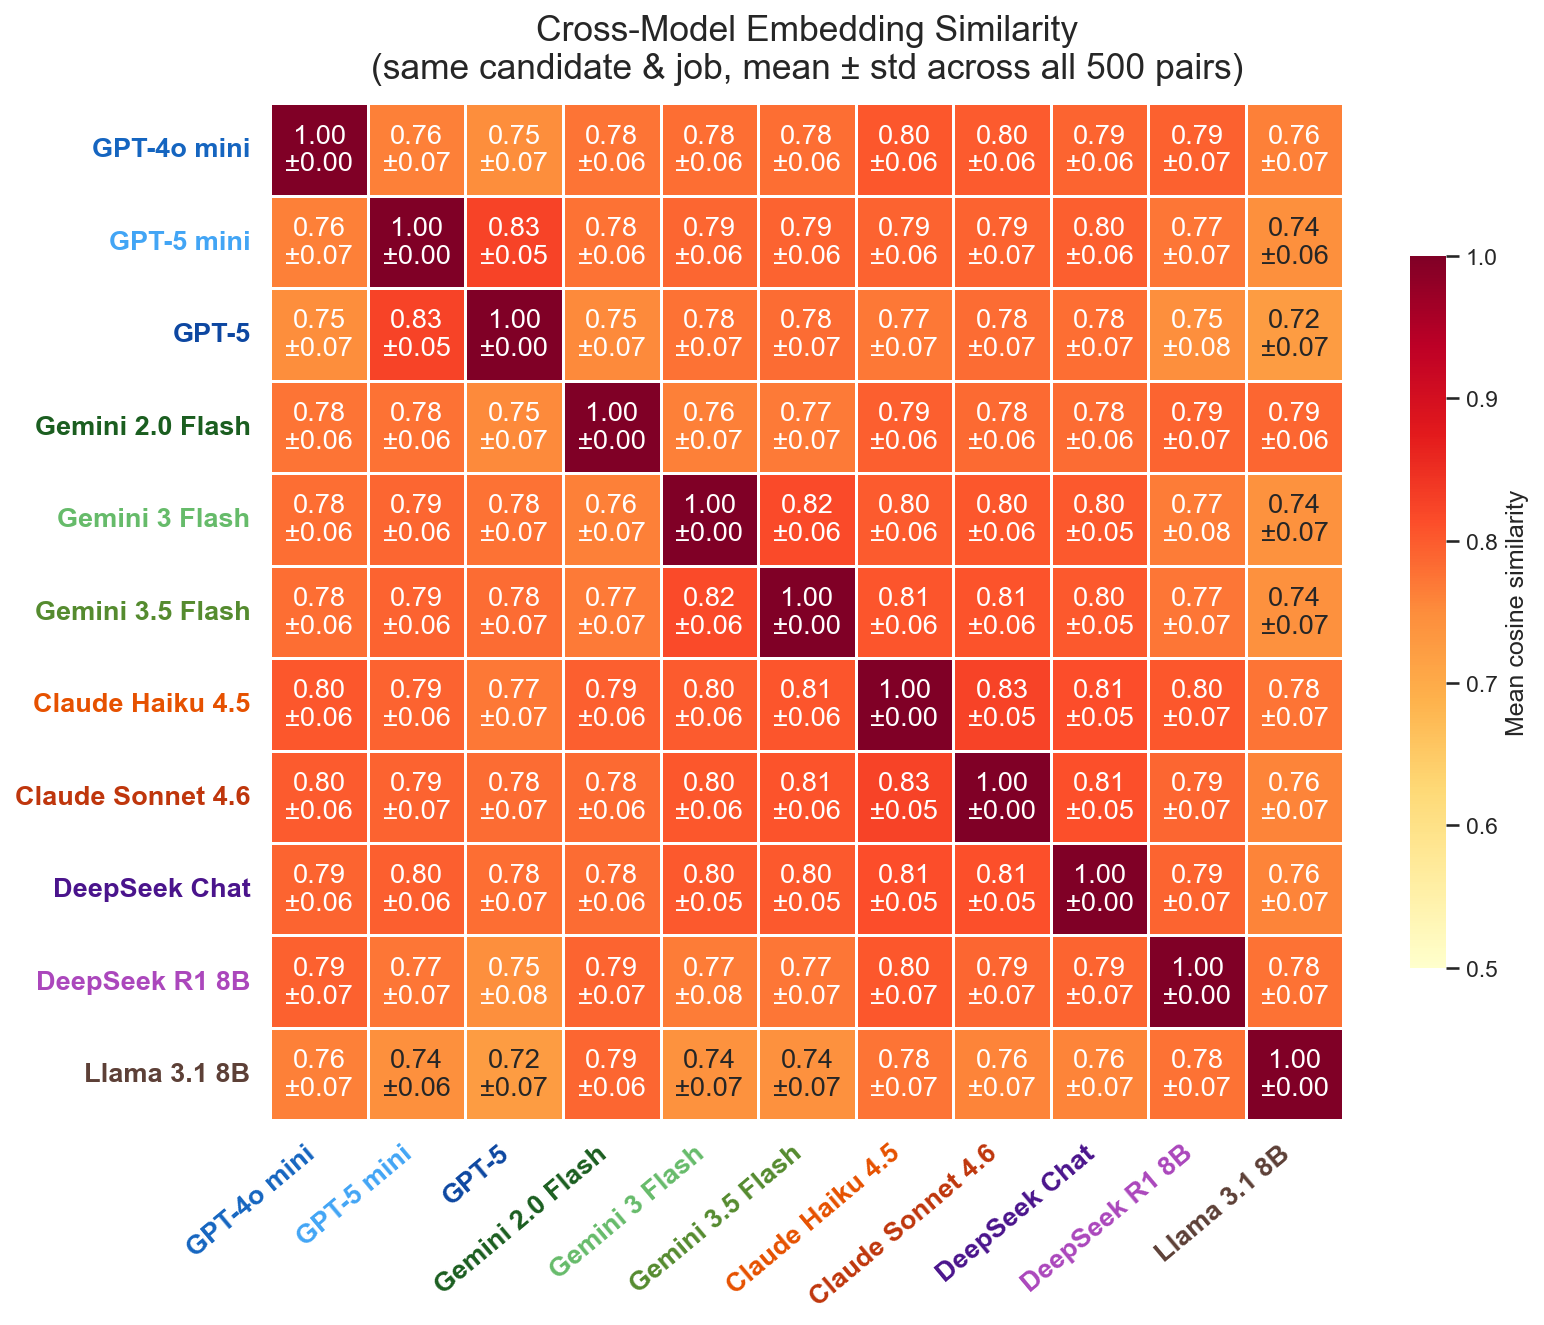

In [11]:
display(Image("output_plots/cl_features/cl_cross_model_similarity.png"))

Mean ± std cosine similarity between embeddings from two different models for the same candidate.
Values are relatively high (0.6–0.8), confirming that the *semantic content* of cover letters
converges across models. The diagonal (same model) is 1.0 by definition.


### 5b. Between-Model Feature Profiles

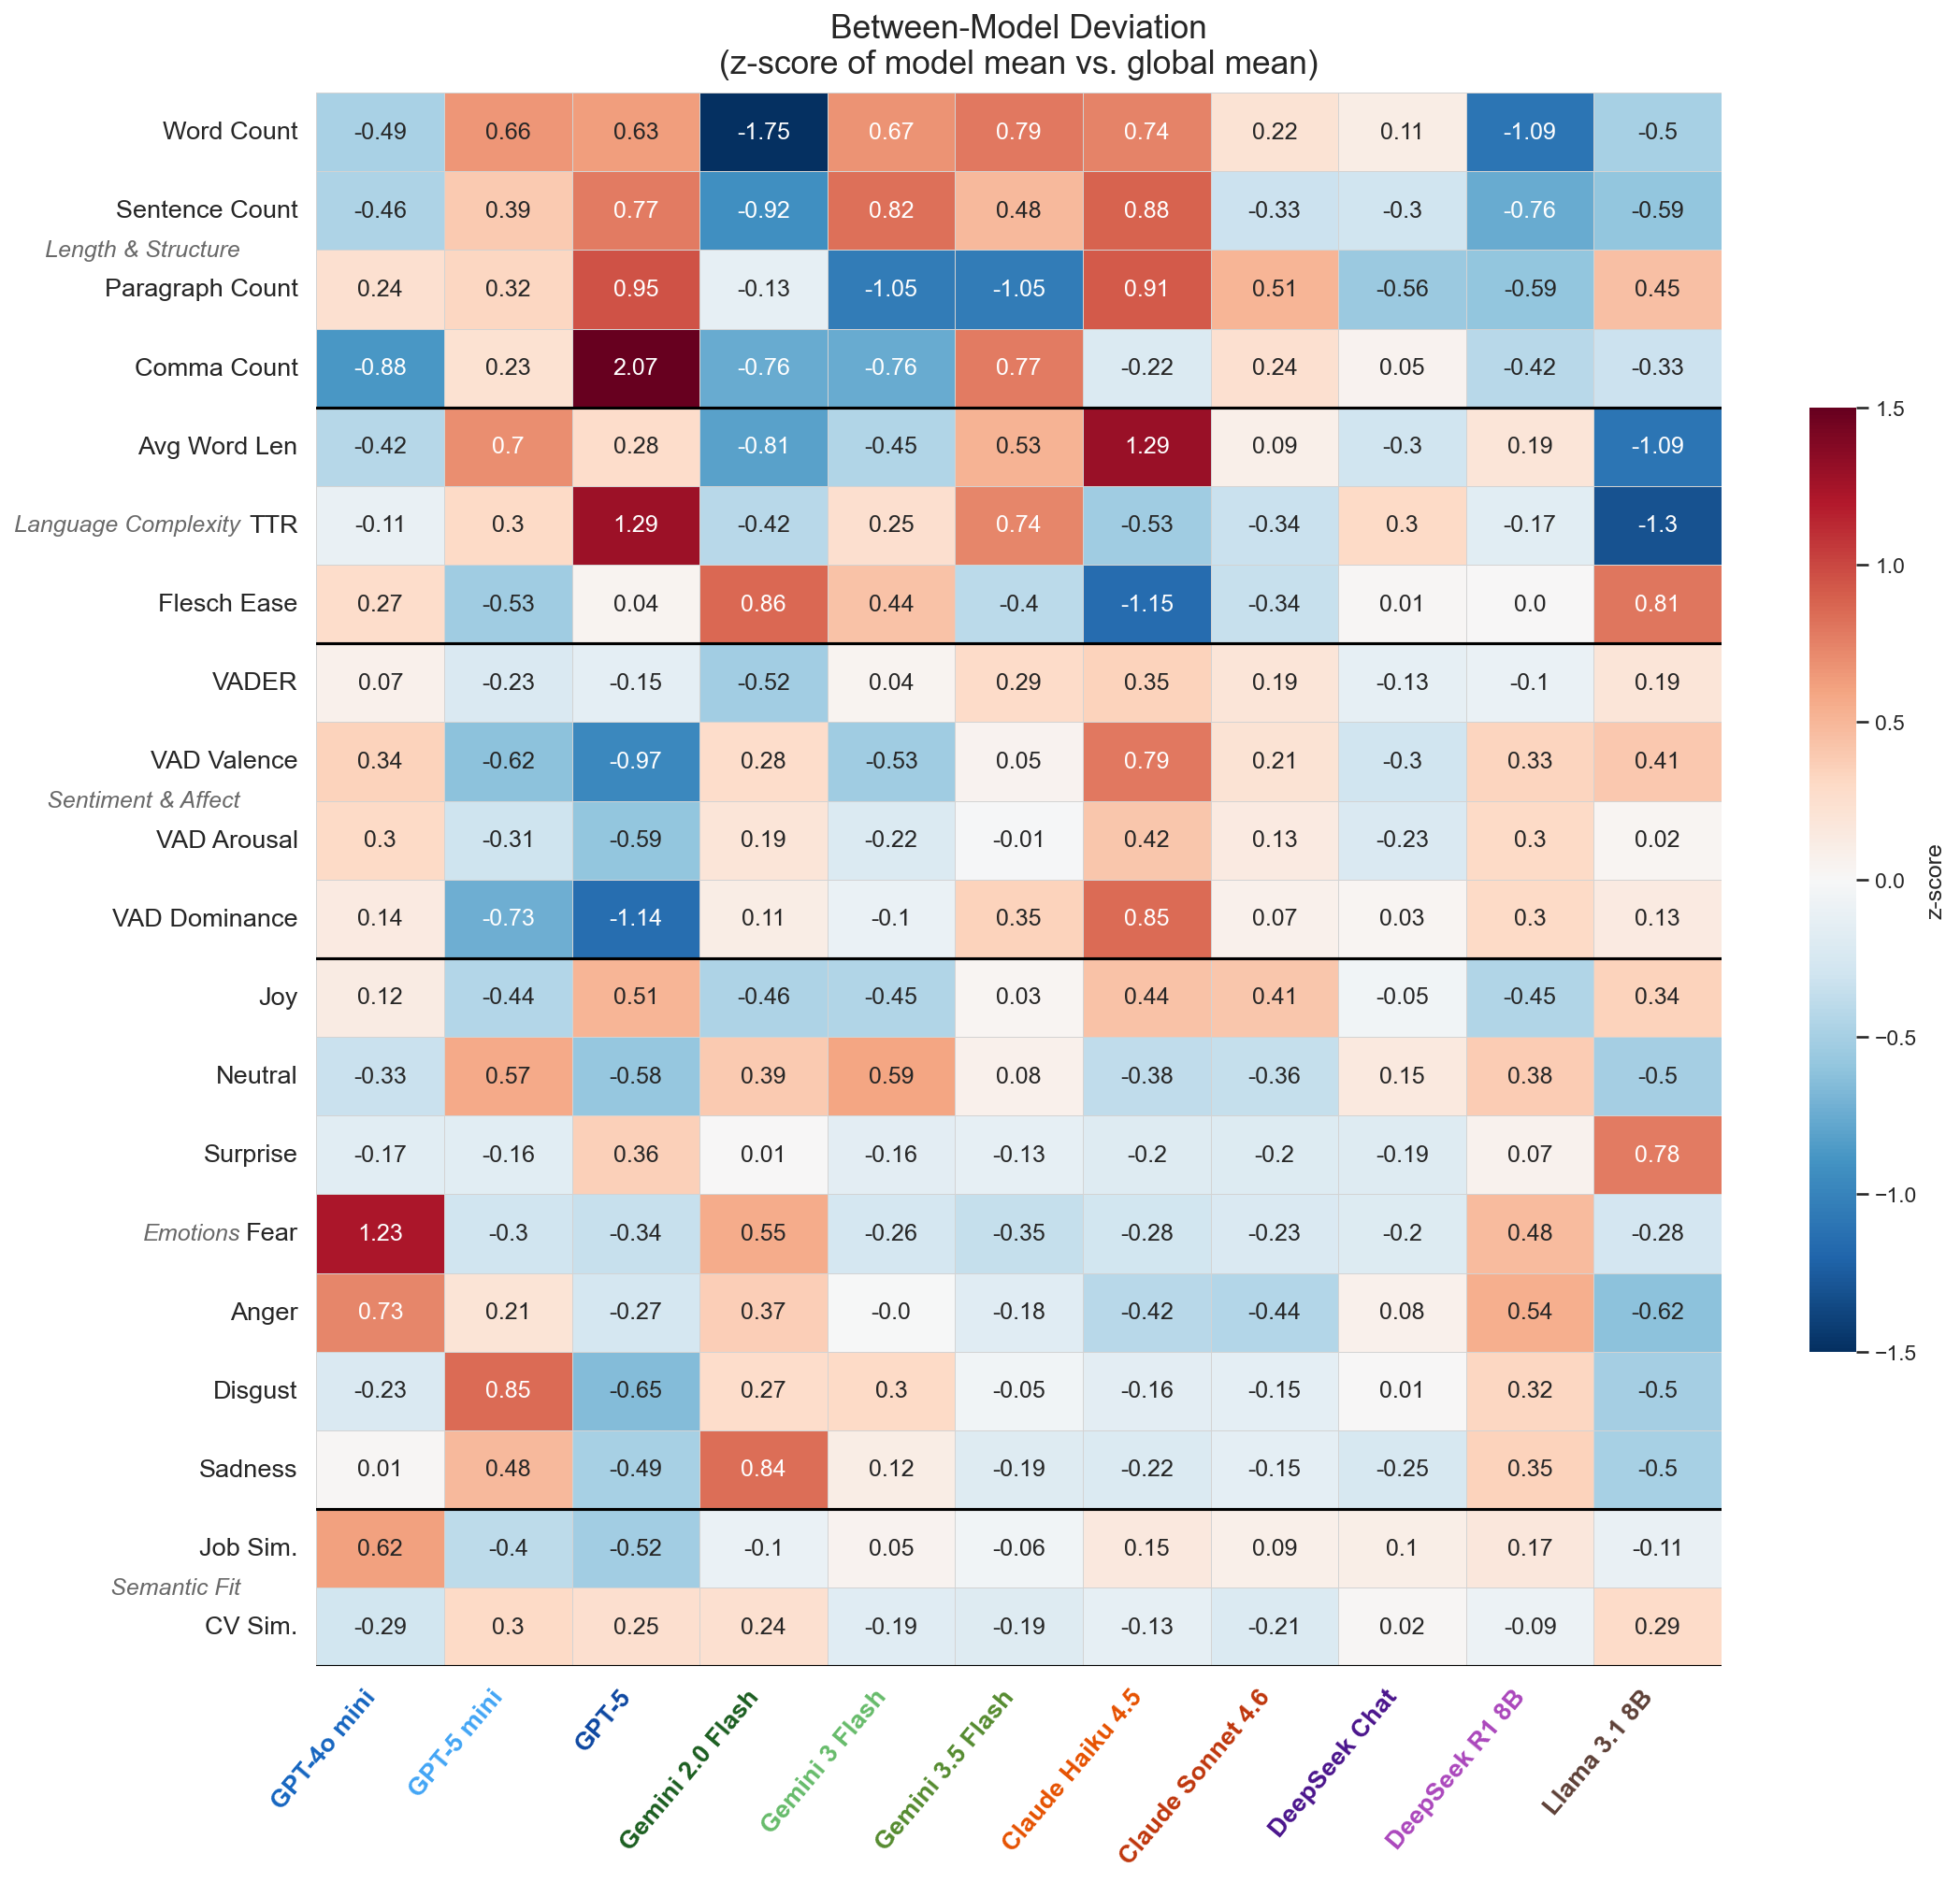

In [12]:
display(Image("output_plots/cl_features/cl_between_model_deviation.png"))

Z-score of each model's mean feature value relative to the global mean.
Red = above average, blue = below average.
Even though semantic content converges, models have distinct profiles on surface and lexical features —
the differentiation happens below the embedding level.


---
## 6. What Do Evaluator Models Reward?

Spearman ρ between each text feature and the score assigned by each evaluator,
in two conditions: CV + Cover Letter and Cover Letter Only.
Stars indicate p < 0.05 (uncorrected).


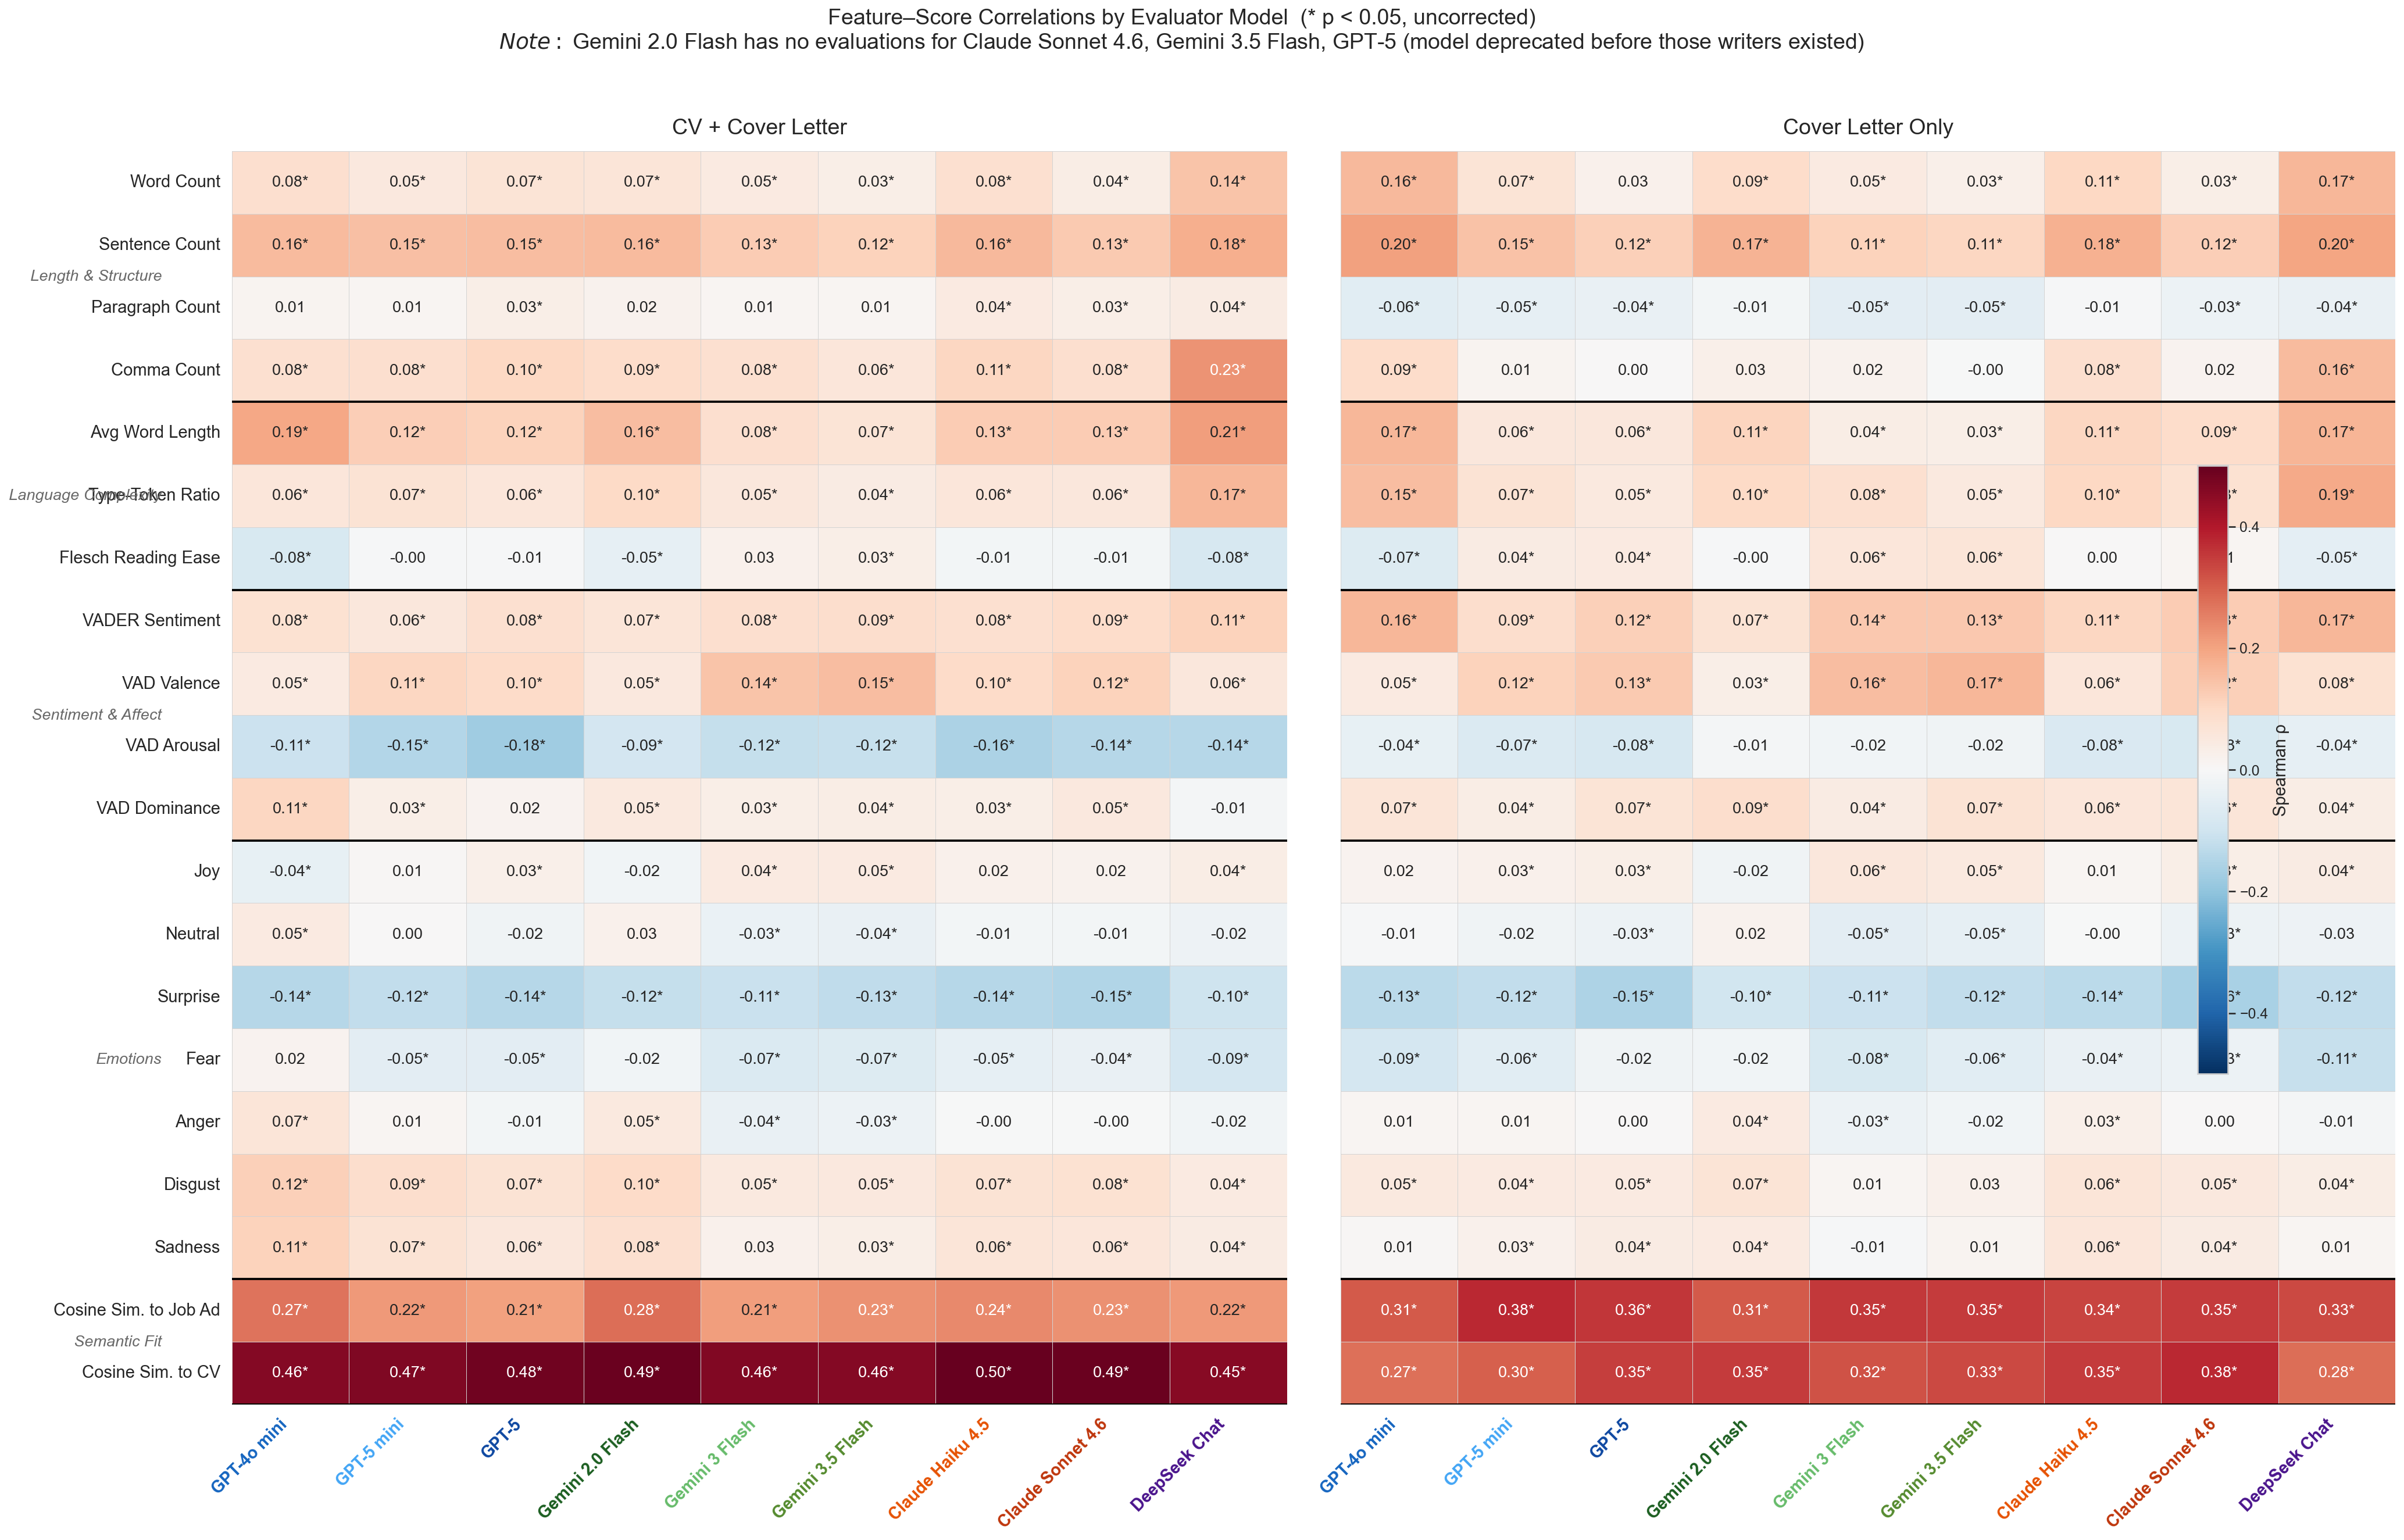

In [13]:
display(Image("output_plots/cl_features/feature_score_corr.png"))

**Key findings:**
- **Cosine similarity to the job description** is one of the most consistently rewarded features —
  evaluators favour letters that mirror the language of the job ad.
- **Dominance** (assertive language) shows positive correlations for several evaluators,
  suggesting confident phrasing is rewarded.
- **Sentiment features** (VADER, valence) show weak or inconsistent effects,
  consistent with their uniformity across all models.
- There is meaningful **evaluator heterogeneity**: models do not all reward the same features.


---
## 7. Key Takeaways

| # | Finding |
|---|---|
| 1 | **Sentiment is uniformly positive** across all models — not a useful discriminating feature. |
| 2 | **Models adapt to the job, not the candidate.** Semantic content is driven by the job description; within-job variation across candidates is small. |
| 3 | **GPT-4o mini homogenises most; Llama 3.1 8B preserves individuality most.** |
| 4 | **Tier split explains little within-job variance.** Models do not write meaningfully different letters for stronger vs. weaker candidates. |
| 5 | **Semantic content converges across models** — differences live at the lexical/stylistic level, visible in keyness and feature profiles. |
| 6 | **Evaluators reward job-relevance and assertiveness** (cosine sim. to job ad, VAD dominance), with notable heterogeneity across evaluator models. |
